# 01 · Data Exploration
Exploratory analysis of the **live Wallapop scrape** (real second-hand iPhone listings in Spain). We look at volume, the spec-parser's coverage, and how price varies by model, storage and city.

In [1]:
import os, sys
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 120)
%matplotlib inline

In [2]:
from src.data import latest_parquet, load_parquet
from src.features.parser import parse_listing
raw_path = latest_parquet('data/raw', 'wallapop_iphones')
df = load_parquet(raw_path)
print('listings:', len(df), '| from', raw_path.name)
df[['title','price','city','n_photos']].head()

listings: 8262 | from wallapop_iphones_20260617.parquet


,title,price,city,n_photos
0,iPhone 11 Blanco 128GB,105.0,Torrejón de Ardoz,5
1,iPhone 11 Negro,100.0,Pozuelo de Alarcón,1
2,iPhone 11 64GB Negro,70.0,Madrid,4
3,iPhone 11 Blanco,150.0,Madrid,4
4,iPhone 11,130.0,Madrid,2


### Parser coverage
How often we can extract each structured field from free-text Spanish listings.

In [3]:
specs = pd.DataFrame([parse_listing(t,d) for t,d in zip(df.title, df.description)])
cov = {c: f'{100*specs[c].notna().mean():.0f}%' for c in ['model_family','storage_gb','battery_pct','color','condition_label']}
cov['is_iphone'] = f'{100*specs.is_iphone.mean():.0f}%'
pd.Series(cov, name='coverage').to_frame()

,coverage
model_family,97%
storage_gb,49%
battery_pct,32%
color,73%
condition_label,35%
is_iphone,100%


### Price distribution by model
The market price gradient the model must learn — note the clean monotonic increase from SE → 16 Pro Max.

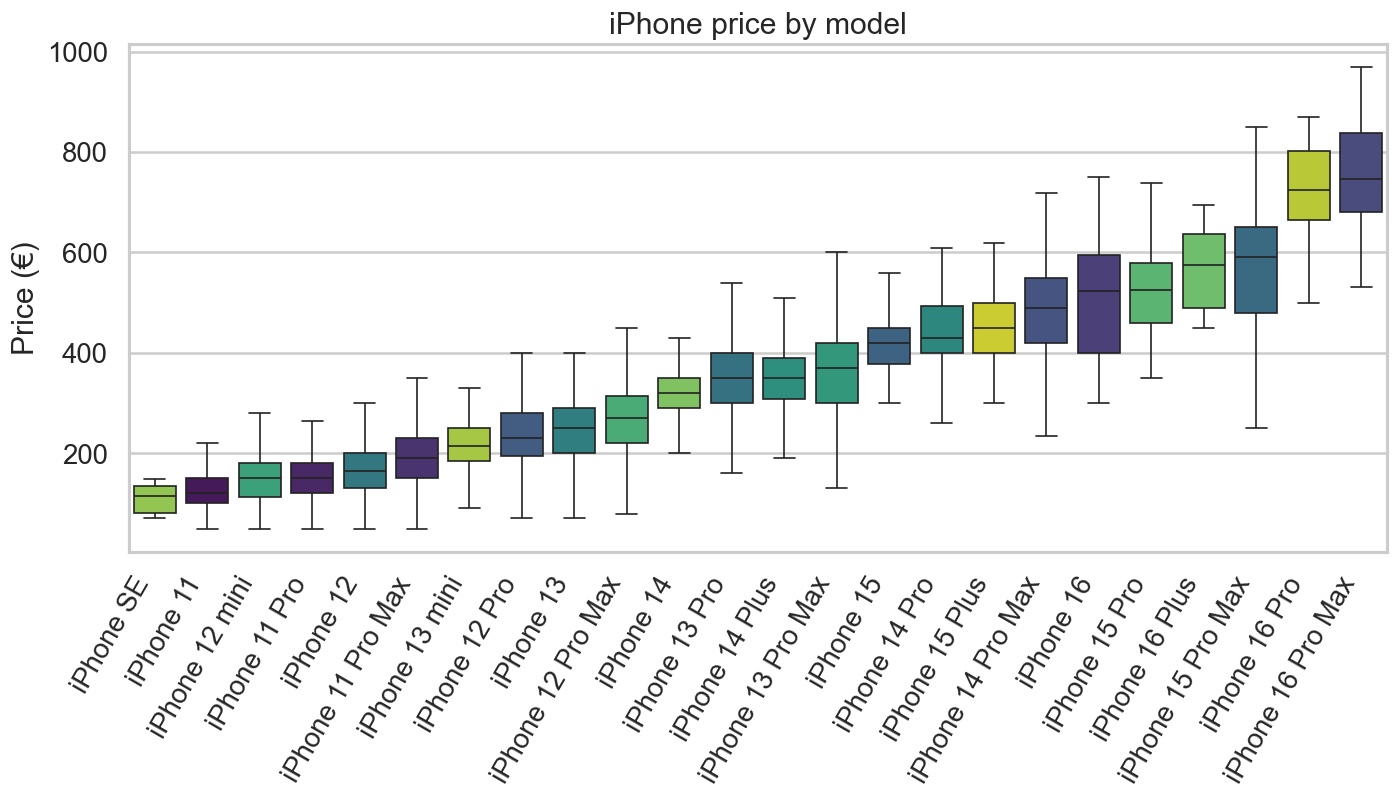

In [4]:
from src.reporting import viz
eda = df.assign(model_family=specs['model_family'])
eda = eda[eda.model_family.notna() & eda.price.between(50,2500)]
p = viz.price_by_model(eda, 'model_family', 'price', 'artifacts/reports/eda_price_by_model.png')
from IPython.display import Image; Image(str(p))

In [5]:
# median price by storage tier
s = df.assign(storage=specs.storage_gb).dropna(subset=['storage'])
s[s.price.between(50,2500)].groupby('storage').price.median()

storage
64.0      145.0
128.0     310.0
256.0     390.0
512.0     460.0
1024.0    639.0
Name: price, dtype: float64

### Listings by city

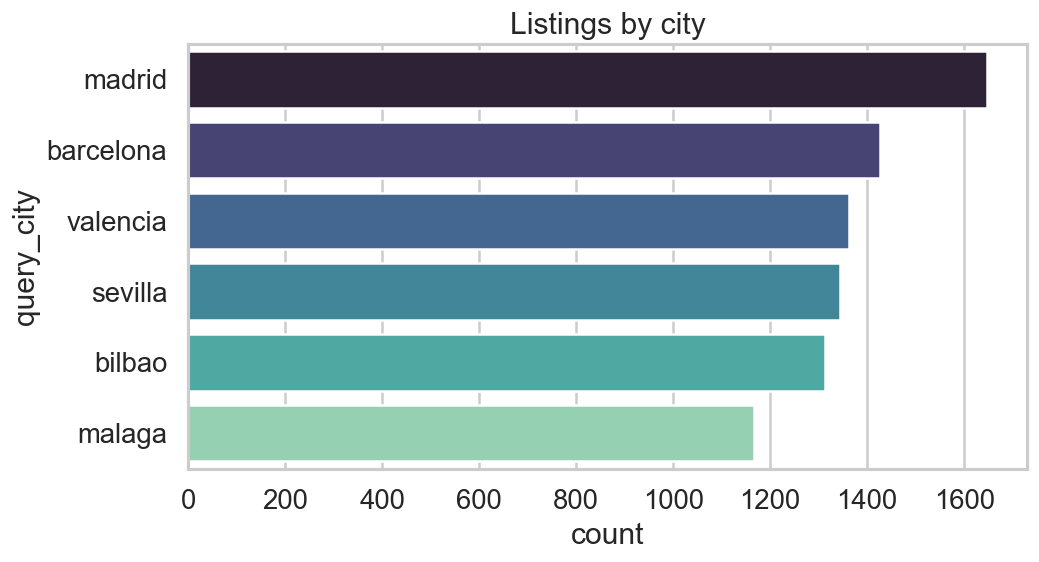

In [6]:
p = viz.deals_by_city(df, 'query_city', 'artifacts/reports/eda_by_city.png')
Image(str(p))

**Takeaways:** ~97% of listings are identifiable iPhones; storage/battery are only partially stated by sellers (hence imputation downstream); the price-by-model gradient is clean and learnable.